# Monte Carlo Simulation of the OU Process under $\mathbb{P}$ and $\mathbb{Q}$

With the parameters estimated, we can now simulate trajectories of the modified
Ornstein-Uhlenbeck process for our cities.

The continuous-time process is:
$$dT_t = \left(\theta'_t + \kappa(\theta_t - T_t)\right)dt + \sigma_t\,dW_t$$

where $\theta'_t = \frac{d\theta}{dt}$ is the analytical derivative of the seasonal function
(computed from the estimated Fourier coefficients).

The Euler-Maruyama discretization with step $\Delta t = 1$ day gives:
$$T_{t+1} = T_t + \left(\theta'_t + \kappa(\theta_t - T_t)\right)\Delta t + \sigma_t\sqrt{\Delta t}\cdot Z_t, \qquad Z_t \stackrel{iid}{\sim} \mathcal{N}(0,1)$$

We simulate $N$ independent trajectories over the pricing horizon. Validation consists of
comparing the simulated temperature distribution against history, and checking the
reproduction of seasonal extremes (distribution tails).

In [1]:
import sys; sys.path.append("../../src")
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import CLEANED_DIR, BASE_TEMP
from ou_simulation import load_ou_params, simulate_ou, x0_from_dataset
from pricing import (hdd_cumulative, cdd_cumulative, get_season_windows,
                     hdd_strike_atm, price_hdd_mc, price_hdd_gaussian,
                     proba_hdd_zero, sensitivity_lambda, _hdd_moments)
from temperature_mc import ALL_CITIES

plt.rcParams.update({
    "font.family": "serif", "font.size": 10, "axes.titlesize": 11,
    "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
})

FOCUS = "chicago"
START, END = "2022-11-01", "2023-03-31"        
N = 10_000
params = {c: load_ou_params(c) for c in ALL_CITIES}
dfs    = {c: pd.read_csv(f"{CLEANED_DIR}/{c}_ou_dataset.csv", parse_dates=["DATE"])
              .set_index("DATE") for c in ALL_CITIES}
real_T   = dfs[FOCUS].loc[START:END, "T"]
hdd_real = float(np.maximum(BASE_TEMP - real_T, 0).sum())

## OU Process under the physical measure $\mathbb{P}$

### OU Process Model and Simulation

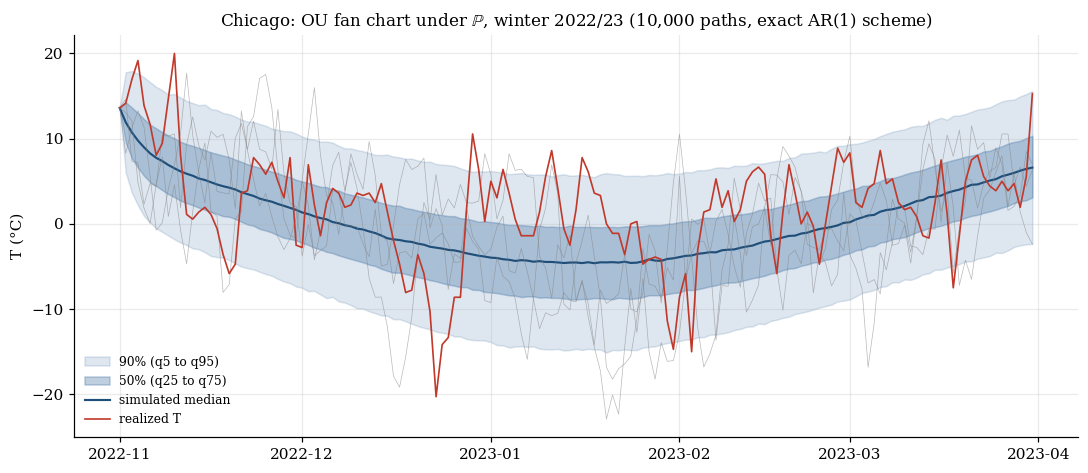

In [2]:
# Simulation under P, starting from the observed state X_s: fan chart vs realized
traj = simulate_ou(params[FOCUS], START, END, n_sims=N,
                   X0=x0_from_dataset(FOCUS, START), seed=42)
q = traj.quantile([0.05, 0.25, 0.5, 0.75, 0.95], axis=1).T

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.fill_between(q.index, q[0.05], q[0.95], color="#4878a8", alpha=0.18, label="90% (q5 to q95)")
ax.fill_between(q.index, q[0.25], q[0.75], color="#4878a8", alpha=0.35, label="50% (q25 to q75)")
ax.plot(q.index, q[0.50], color="#1f4e79", lw=1.4, label="simulated median")
ax.plot(traj.index, traj.iloc[:, :3], color="grey", lw=0.45, alpha=0.55)
ax.plot(real_T.index, real_T.values, color="#c0392b", lw=1.1, label="realized T")
ax.set_ylabel("T (°C)")
ax.set_title(f"{FOCUS.title()}: OU fan chart under $\\mathbb{{P}}$, winter 2022/23 "
             f"({N:,} paths, exact AR(1) scheme)")
ax.legend(frameon=False, loc="lower left", fontsize=8)
fig.tight_layout()

### $HDD$ and $CDD$ Distribution

Now that we can simulate temperature paths for each city, we can build the climate
indices that serve as underlyings for weather-derivative contracts.

For a given day $i$ and reference temperature $T_{\text{ref}} = 18°C$, the Heating Degree Day
(HDD) and Cooling Degree Day (CDD) are defined as:

$$\text{HDD}_i = \max(0,\ T_{\text{ref}} - T_i)$$
$$\text{CDD}_i = \max(0,\ T_i - T_{\text{ref}})$$

The cumulative index over a contract period $[\tau_1, \tau_2]$ is:

$$\text{HDD} = \sum_{i=\tau_1}^{\tau_2} \text{HDD}_i \qquad \text{CDD} = \sum_{i=\tau_1}^{\tau_2} \text{CDD}_i$$


Below we compare the simulated distributions of these indices against observed values to validate the model's consistency before moving to pricing under the risk-neutral measure $\mathbb{Q}$.

,simulated E[HDD],simulated σ,realized 22/23,realized quantile
city,,,,
chicago,2690.4,165.4,2430.1,0.1
new_york,2052.0,127.4,1741.8,0.0
boston,2332.3,115.6,2052.4,0.0
minneapolis,3260.4,190.9,3333.1,0.6
dallas,1068.1,133.8,943.0,0.2
los_angeles,461.5,73.0,671.1,1.0
seattle,1664.1,89.7,1886.6,1.0


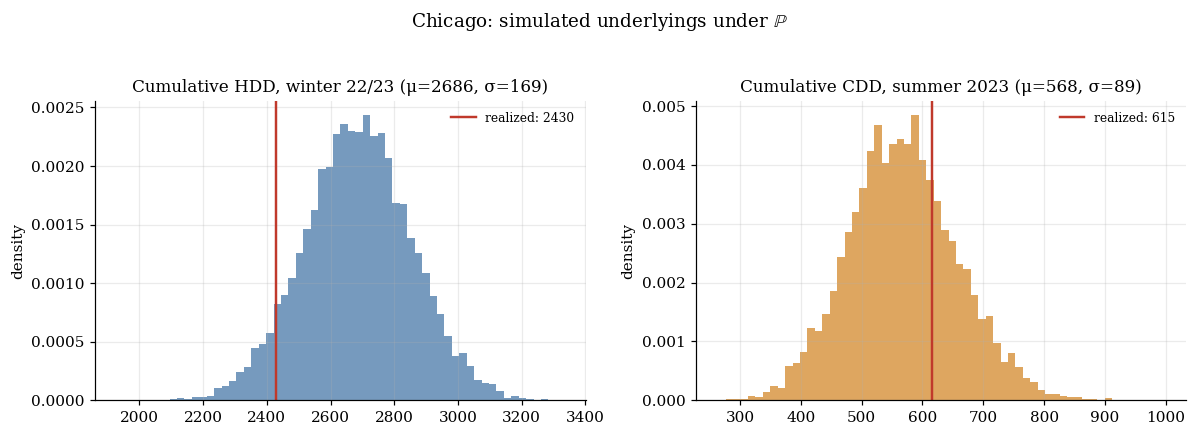

In [3]:
# Simulated HDD (winter) and CDD (summer) distributions: focus city
win = get_season_windows(2023, 2023)
ws, we = win["winter"][2023]; ss, se = win["summer"][2023]
hdd_w = hdd_cumulative(simulate_ou(params[FOCUS], ws, we, n_sims=N,
                                   X0=x0_from_dataset(FOCUS, ws), seed=1))
cdd_s = cdd_cumulative(simulate_ou(params[FOCUS], ss, se, n_sims=N, seed=1))
cdd_real = float(np.maximum(dfs[FOCUS].loc[ss:se, "T"] - BASE_TEMP, 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(hdd_w, bins=60, density=True, color="#4878a8", alpha=0.75)
axes[0].axvline(hdd_real, color="#c0392b", lw=1.6, label=f"realized: {hdd_real:.0f}")
axes[0].set_title(f"Cumulative HDD, winter 22/23 (μ={hdd_w.mean():.0f}, σ={hdd_w.std():.0f})")
axes[1].hist(cdd_s, bins=60, density=True, color="#d4882b", alpha=0.75)
axes[1].axvline(cdd_real, color="#c0392b", lw=1.6, label=f"realized: {cdd_real:.0f}")
axes[1].set_title(f"Cumulative CDD, summer 2023 (μ={cdd_s.mean():.0f}, σ={cdd_s.std():.0f})")
for ax in axes: ax.set_ylabel("density"); ax.legend(frameon=False, fontsize=8)
fig.suptitle(f"{FOCUS.title()}: simulated underlyings under $\\mathbb{{P}}$", y=1.03)
fig.tight_layout()

# 7-city validation: simulated E[HDD] vs realized HDD for winter 22/23
rows = []
for c in ALL_CITIES:
    h = hdd_cumulative(simulate_ou(params[c], ws, we, n_sims=3000,
                                   X0=x0_from_dataset(c, ws), seed=1))
    hr = float(np.maximum(BASE_TEMP - dfs[c].loc[ws:we, "T"], 0).sum())
    rows.append({"city": c, "simulated E[HDD]": h.mean(), "simulated σ": h.std(),
                 "realized 22/23": hr, "realized quantile": (h < hr).mean()})
pd.DataFrame(rows).set_index("city").round(1)

Several observations stand out.

The long-term trend is well captured: in every city, the simulated median reproduces the
gradual decline of HDDs and rise of CDDs, consistent with the warming embedded in the linear
component of $\theta(t)$ ($a+bt$ with $b>0$).

In-sample, observed values mostly fall inside the 5 to 95% confidence band, validating the
calibration under $\mathbb{P}$. The model does not, however, capture `outlier` years with
abnormally warm or cold winters. The realized quantile column above shows how each specific winter sits within the simulated law.

## OU Process under the measure $\mathbb{Q}$

The weather-derivatives market is an **incomplete** market. A market is complete if
every contingent claim can be replicated by a self-financing portfolio of tradable assets.
Temperature is not a tradable asset, so no portfolio replicates a weather derivative's payoff. The risk-neutral measure $\mathbb{Q}$ is therefore not unique.

To obtain unique prices, we introduce a market price of weather risk $\lambda_t=\lambda$ (supposed constant for simplicity in our case), which
parametrizes the choice of $\mathbb{Q}$ among the equivalent measures. 

Applying Girsanov's theorem, set $dW_t^{\mathbb{Q}} = dW_t^{\mathbb{P}} + \lambda\, dt$, which transforms the temperature dynamics under $\mathbb{Q}$ into:

$$dT_t = \left(\theta'_t + \kappa(\theta_t - T_t) - \lambda\sigma_t\right)dt + \sigma_t\, dW_t^{\mathbb{Q}}$$

## Monte Carlo Pricing

The price of a weather derivative with payoff $\Phi$ is:

$$V_0 = e^{-r\tau}\, \mathbb{E}^{\mathbb{Q}}\left[\Phi(H)\right]$$

For an HDD call and put:

$$\Phi_{\text{call}}(H) = \max(H - K,\ 0) \qquad \Phi_{\text{put}}(H) = \max(K - H,\ 0)$$

This expectation has no closed form, so we estimate it by Monte Carlo: simulate $N$
temperature paths $(T_t^{(i)})_{t=t_1}^{t_2}$ under $\mathbb{Q}$, yielding $N$ realizations of
the cumulative HDD $H^{(i)}$, and approximate the expectation by the empirical mean:

$$\hat{V}_0 = \frac{e^{-r\tau}}{N} \sum_{i=1}^{N} \Phi(H^{(i)}) \xrightarrow[N \to \infty]{\mathbb{Q}\text{-a.s.}} V_0$$

By the central limit theorem, the estimator's error is $\mathcal{O}(N^{-1/2})$ and the 95%
confidence interval is:

$$\text{CI}_{95\%} = \pm\, 1.96 \cdot e^{-r\tau} \cdot \frac{\hat{\sigma}_\Phi}{\sqrt{N}}$$

where $\hat{\sigma}_\Phi$ is the empirical standard deviation of the simulated payoffs.

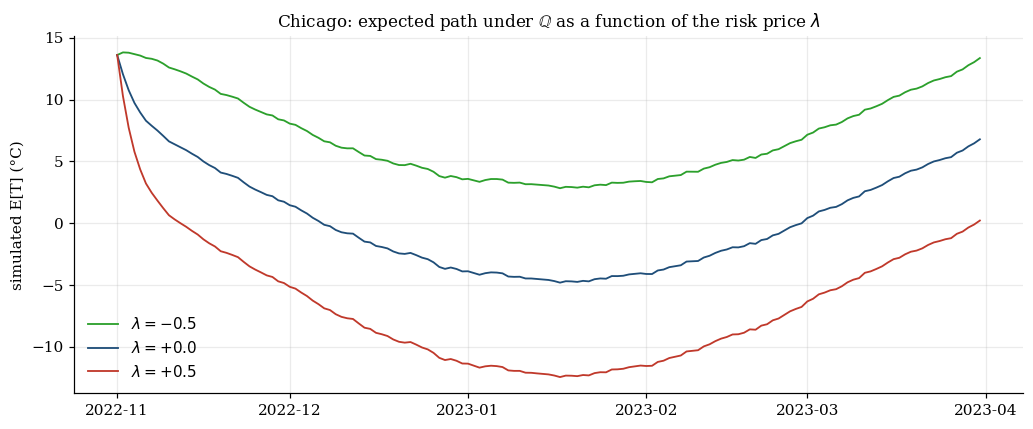

In [4]:
# Effect of the risk price lambda: drift shift under Q
fig, ax = plt.subplots(figsize=(9.5, 4))
for lam, col in [(-0.5, "#2ca02c"), (0.0, "#1f4e79"), (0.5, "#c0392b")]:
    m = simulate_ou(params[FOCUS], START, END, n_sims=2000, lambda_=lam,
                    X0=x0_from_dataset(FOCUS, START), seed=3).mean(axis=1)
    ax.plot(m.index, m.values, lw=1.2, color=col, label=f"$\\lambda={lam:+.1f}$")
ax.set_ylabel("simulated E[T] (°C)")
ax.set_title(f"{FOCUS.title()}: expected path under $\\mathbb{{Q}}$ "
             "as a function of the risk price $\\lambda$")
ax.legend(frameon=False)
fig.tight_layout()

Historical ATM strike: 2586 HDD
Call:   142.04 ± 0.75   |   Put:    24.73 ± 0.75
Parity C−P = +117.32  vs  E[H]−K = +117.32


,lambda,price,ic95,prime_vs_neutre_pct
0,-1.0,0.00,0.00,-100.00
1,-0.5,0.00,0.00,-100.00
2,0.0,142.31,1.06,0.00
3,0.5,1141.69,0.00,702.28
4,1.0,2166.69,0.00,1422.56


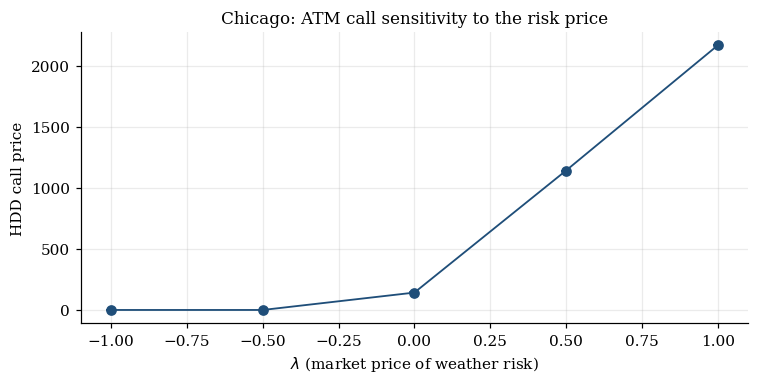

In [5]:
# MC pricing: ATM call/put + lambda sensitivity (common random numbers)
K = round(hdd_strike_atm(FOCUS, list(get_season_windows(2017, 2023)["winter"].values())))
call = price_hdd_mc(params[FOCUS], K, START, END, option_type="C", n_sims=N, seed=7)
put  = price_hdd_mc(params[FOCUS], K, START, END, option_type="P", n_sims=N, seed=7)
print(f"Historical ATM strike: {K} HDD")
print(f"Call: {call['price']:8.2f} ± {call['ic95']:.2f}   |   "
      f"Put: {put['price']:8.2f} ± {put['ic95']:.2f}")
print(f"Parity C−P = {call['price']-put['price']:+.2f}  vs  E[H]−K = {call['hdd_mean']-K:+.2f}")

sens = sensitivity_lambda(params[FOCUS], [-1.0, -0.5, 0.0, 0.5, 1.0],
                          K=K, start_date=START, end_date=END,
                          option_type="C", n_sims=5000)
display(sens.round(2))

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.errorbar(sens["lambda"], sens["price"], yerr=1.96 * sens["ic95"],
            fmt="o-", color="#1f4e79", capsize=3, lw=1.2)
ax.set_xlabel("$\\lambda$ (market price of weather risk)"); ax.set_ylabel("HDD call price")
ax.set_title(f"{FOCUS.title()}: ATM call sensitivity to the risk price")
fig.tight_layout()

## Pricing under the Gaussian approximation (close formula)

In this section we derive an approximate closed-form price for a weather derivative. This approach, introduced by Alaton, Djehiche & Stillberger (2002), rests on a simplifying assumption that is valid in winter.

For a winter contract (November to March), the temperature is almost surely below $T_{ref} = 18°C$, so the truncation in the daily HDD never binds:

$$P(\max(T_{ref} - T_t, 0) = 0) = P(T_t > T_{ref}) \approx 0$$

Under this assumption:

$$H_n = \sum_{i=1}^n \max(T_{ref} - T_{t_i}, 0) = T_{ref} \cdot n - \sum_{i=1}^n T_{t_i}$$

### Contract formalization

We set the contract variables:

- $s$: pricing date (today)
- $t_1$: first day of the measurement period (e.g. November 1st)
- $t_n$: last day of the measurement period (e.g. March 31st)
- $n = t_n - t_1 + 1$: number of days in the measurement period ($n = 151$ for a
  November to March winter)
- $\tau = t_n - s$: time in years between pricing and settlement, used for discounting
  $e^{-r\tau}$

We assume $s \leq t_1$, i.e. the contract is priced before the measurement period starts.

We can now compute $\mu(t, s) = \mathbb{E}^{\mathbb{Q}}[T_t | \mathcal{F}_s]$ for each day
$t \in \{t_1, \ldots, t_n\}$ of the measurement period.

Under $\mathbb{P}$, the exact solution of the OU process gives:

$$\mathbb{E}^{\mathbb{P}}[T_t | \mathcal{F}_s] = \theta(t) + (T_s - \theta(s))e^{-\kappa(t-s)}$$

Since $\sigma$ is constant within each day, the Girsanov integral discretizes exactly:

$$\mu(t, s) = \mathbb{E}^{\mathbb{Q}}[T_t | \mathcal{F}_s] = \mathbb{E}^{\mathbb{P}}[T_t | \mathcal{F}_s]
- \frac{\lambda}{\kappa}(1-e^{-\kappa}) \sum_{i=s+1}^{t} \sigma_i e^{-\kappa(t-i)}$$

Under the winter assumption, $H_n = n \cdot T_{ref} - \sum_{i=1}^n T_{t_i}$, and by linearity
of expectation:

$$\boxed{h(n, s) = \mathbb{E}^{\mathbb{Q}}[H_n | \mathcal{F}_s] = n \cdot T_{ref} - \sum_{i=1}^{n} \mu(t_i, s)}$$

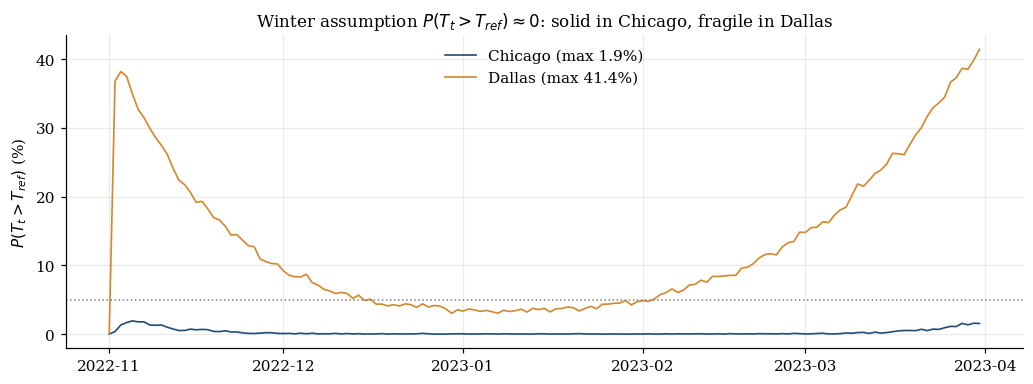

In [6]:
# Validity of the winter assumption: P(T_t > T_ref) day by day
p_focus  = proba_hdd_zero(params[FOCUS],  START, END, n_sims=5000, seed=2)
p_dallas = proba_hdd_zero(params["dallas"], START, END, n_sims=5000, seed=2)

fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.plot(p_focus.index, p_focus * 100, color="#1f4e79", lw=1.1,
        label=f"{FOCUS.title()} (max {p_focus.max():.1%})")
ax.plot(p_dallas.index, p_dallas * 100, color="#d4882b", lw=1.1,
        label=f"Dallas (max {p_dallas.max():.1%})")
ax.axhline(5, color="grey", ls=":", lw=1)
ax.set_ylabel("$P(T_t > T_{ref})$ (%)")
ax.set_title("Winter assumption $P(T_t > T_{ref}) \\approx 0$: solid in Chicago, fragile in Dallas")
ax.legend(frameon=False)
fig.tight_layout()

For the variance, a similar computation yields:

$$V(t, s) = \text{Var}(T_t | \mathcal{F}_s) = \frac{1-e^{-2\kappa}}{2\kappa}
\sum_{i=s+1}^{t} \sigma_i^2\, e^{-2\kappa(t-i)}$$

To move to the variance of $H_n$, note that $n \cdot T_{ref}$ is a constant, so:

$$\Lambda^2(n, s) = \text{Var}(H_n | \mathcal{F}_s) = \text{Var}\!\left(\sum_{i=1}^{n} T_{t_i} \,\bigg|\, \mathcal{F}_s\right) = \sum_{i=1}^{n} V(t_i, s) + 2\sum_{i<j} \text{Cov}(T_{t_i}, T_{t_j} | \mathcal{F}_s)$$

Using the covariance result:

$$\text{Cov}(T_{t_i}, T_{t_j} | \mathcal{F}_s) = e^{-\kappa(t_j - t_i)} V(t_i, s)$$

then factoring $V(t_i, s)$ and summing the geometric series in $j$:

$$\boxed{\Lambda^2(n, s) = \sum_{i=1}^{n} V(t_i, s)\left(1 + \frac{2e^{-\kappa}(1 - e^{-\kappa(n-i)})}{1 - e^{-\kappa}}\right)}$$

In [7]:
# Analytic moments (O(n) recurrences) vs Monte Carlo cross-validation
rows = []
for lam in [0.0, 0.5]:
    for pdate in [None, "2022-09-01"]:
        h, Lam, n = _hdd_moments(params[FOCUS], START, END, lambda_=lam, pricing_date=pdate)
        mc = price_hdd_mc(params[FOCUS], K, START, END, lambda_=lam,
                          pricing_date=pdate, n_sims=10_000, seed=11)
        rows.append({"lambda": lam, "pricing s": pdate or START,
                     "analytic h(n,s)": h, "MC μ_H": mc["hdd_mean"],
                     "analytic √Λ": np.sqrt(Lam), "MC σ_H": mc["hdd_std"]})
pd.DataFrame(rows).round(1)

,lambda,pricing s,"analytic h(n,s)",MC μ_H,analytic √Λ,MC σ_H
0,0.0,2022-11-01,2702.7,2703.3,169.2,167.7
1,0.0,2022-09-01,2702.7,2703.5,170.1,168.7
2,0.5,2022-11-01,3727.7,3727.7,169.2,168.0
3,0.5,2022-09-01,3749.8,3749.8,170.1,169.1


With all of this in place, the analytic price of the HDD call follows.
Since $H_n | \mathcal{F}_s \sim \mathcal{N}(h(n,s),\ \Lambda(n,s))$:

$$c(n, s) = e^{-r(t_n - s)}\, \mathbb{E}^{\mathbb{Q}}\left[\max(H_n - K, 0) \,|\, \mathcal{F}_s\right]$$

$$= e^{-r(t_n-s)}\left[(h(n,s) - K)\,\Phi(-\alpha_n(s)) + \Lambda(n,s)\,\phi(\alpha_n(s))\right]$$

with:

$$\alpha_n(s) = \frac{K - h(n,s)}{\Lambda(n,s)}$$

where $\Phi$ is the standard normal CDF and $\phi$ its density.

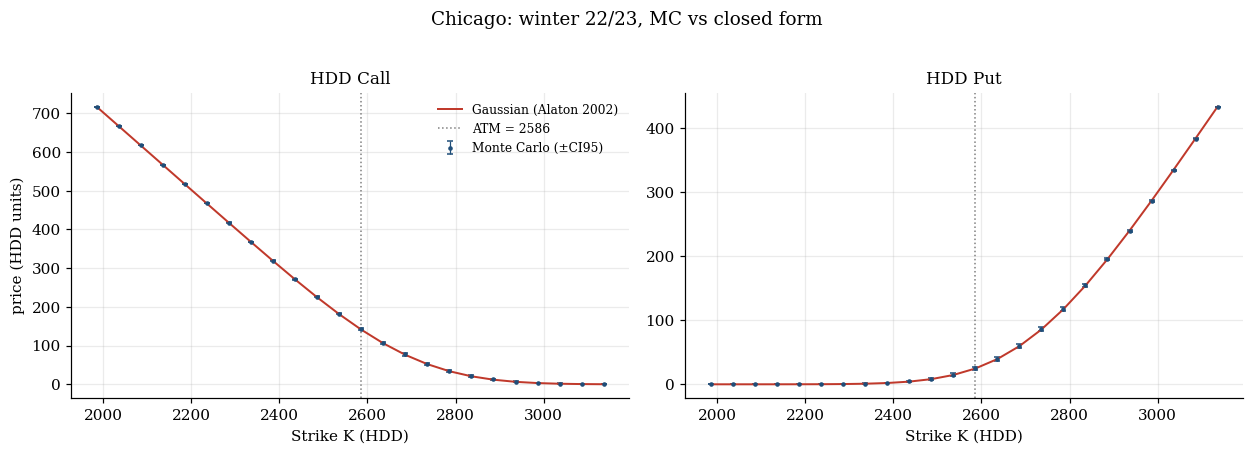

In [8]:
# Price curves: Monte Carlo (±CI95) vs Gaussian closed form, call and put
strikes = np.arange(K - 600, K + 600, 50)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4), sharex=True)
for ax, typ, ttl in [(axes[0], "C", "HDD Call"), (axes[1], "P", "HDD Put")]:
    mc_p, mc_ic, ga_p = [], [], []
    for Ki in strikes:
        m = price_hdd_mc(params[FOCUS], Ki, START, END, option_type=typ,
                         n_sims=4000, seed=5)
        mc_p.append(m["price"]); mc_ic.append(m["ic95"])
        ga_p.append(price_hdd_gaussian(params[FOCUS], Ki, START, END, option_type=typ))
    ax.errorbar(strikes, mc_p, yerr=1.96 * np.array(mc_ic), fmt=".", ms=4,
                color="#1f4e79", capsize=2, lw=0.8, label="Monte Carlo (±CI95)")
    ax.plot(strikes, ga_p, color="#c0392b", lw=1.3, label="Gaussian (Alaton 2002)")
    ax.axvline(K, color="grey", ls=":", lw=1, label=f"ATM = {K}")
    ax.set_title(ttl); ax.set_xlabel("Strike K (HDD)")
axes[0].set_ylabel("price (HDD units)")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(f"{FOCUS.title()}: winter 22/23, MC vs closed form", y=1.02)
fig.tight_layout()

### Validity of the Gaussian approximation

The Gaussian approximation rests on the winter assumption:

$$P(T_t > T_{ref}) \approx 0 \quad \forall t \in [t_1, t_n]$$

**HDD call**: the assumption holds, the call pays in cold scenarios ($H_n > K$), precisely
where $T_t \ll T_{ref}$ and the truncation never binds. The relative gap to Monte Carlo stays
below 5% in the ITM/ATM zone.

**HDD put**: the assumption is violated, the put pays in warm scenarios ($H_n < K$), where
some days have $T_t > T_{ref}$. The Gaussian then overstates $H_n$ because it ignores the
truncation, which systematically inflates the price. The relative gap can reach 10 to 30% at the money (not visible here in the graph because of the order of magnitude)

**Conclusion**: the Gaussian approximation of Alaton et al. (2002) is reliable for pricing **winter HDD calls** on cold-climate cities (Chicago, Minneapolis). It is less suited to HDD puts, for which Monte Carlo remains the reference method.

In [9]:
# Pipeline novelty: pricing a FUTURE winter (beyond the data),
# theta(t) and sigma_X(doy) are rebuilt analytically from the artifact.
fut = price_hdd_mc(params[FOCUS], K, "2026-11-01", "2027-03-31", n_sims=N, seed=7)
gau = price_hdd_gaussian(params[FOCUS], K, "2026-11-01", "2027-03-31")
print(f"Winter 2026/27 (K={K}): MC call = {fut['price']:.1f} ± {fut['ic95']:.1f} "
      f"| Gaussian = {gau:.1f} | E[HDD] = {fut['hdd_mean']:.0f}")

Winter 2026/27 (K=2586): MC call = 132.8 ± 0.8 | Gaussian = 132.0 | E[HDD] = 2691
